# API Response Time: Before vs After Indexing
Compares response times from two log files to measure the impact of database indexing.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Configuration

In [2]:
BEFORE_LOG = "before_index.log"   # Log file captured BEFORE adding indexes
AFTER_LOG  = "after_index.log"    # Log file captured AFTER adding indexes

## Log Parser
Matches your log format:
```
2026-03-21T14:05:51.366Z - POST /api/auth/login 200 190.622 ms - 297
```

In [3]:
# FIXED: matches  TIMESTAMP - METHOD /endpoint STATUS  time ms - size
pattern = re.compile(
    r'\S+\s+-\s+(\S+)\s+(\S+)\s+(\d+)\s+([\d\.]+)\s+ms'
)

def normalize_endpoint(endpoint):
    """Replace numeric path segments with :id  e.g. /api/users/6 -> /api/users/:id"""
    return re.sub(r'/\d+', '/:id', endpoint)

def parse_log(filepath):
    api_data    = {}
    status_data = {}
    discarded   = []
    total       = 0

    with open(filepath, "r") as f:
        for line in f:
            total += 1
            match = pattern.search(line)
            if match:
                method   = match.group(1)
                endpoint = match.group(2)
                status   = match.group(3)
                rt       = float(match.group(4))

                if not endpoint.startswith("/api/"):
                    discarded.append({"Line": line.strip(), "Reason": "Not /api/ endpoint"})
                    continue

                key = f"{method} {normalize_endpoint(endpoint)}"
                api_data.setdefault(key, []).append(rt)
                status_data.setdefault(key, []).append(status)
            else:
                discarded.append({"Line": line.strip(), "Reason": "Regex did not match"})

    api_count = sum(len(v) for v in api_data.values())
    print(f"[{filepath}]")
    print(f"  Total lines    : {total}")
    print(f"  /api/ matched  : {api_count}")
    print(f"  Discarded      : {len(discarded)}")
    print(f"  Endpoints found: {list(api_data.keys())}\n")
    return api_data, status_data, discarded

def compute_stats(api_data, status_data, label):
    rows = []
    for key, times in api_data.items():
        arr    = np.array(times)
        q1, q3 = np.percentile(arr, [25, 75])
        iqr    = q3 - q1
        mask   = (arr >= q1 - 1.5*iqr) & (arr <= q3 + 1.5*iqr)
        rows.append({
            "MethodEndpoint" : key,
            "Label"          : label,
            "Count"          : len(arr),
            "Mean(ms)"       : arr.mean(),
            "RobustMean(ms)" : arr[mask].mean() if mask.any() else np.nan,
            "Median(ms)"     : np.median(arr),
            "95thPerc(ms)"   : np.percentile(arr, 95),
            "Max(ms)"        : arr.max(),
            "Min(ms)"        : arr.min(),
            "Statuses"       : status_data[key],
            "AllTimes"       : times,
        })
    return pd.DataFrame(rows)

## Parse Both Log Files

In [4]:
before_api, before_status, before_disc = parse_log(BEFORE_LOG)
after_api,  after_status,  after_disc  = parse_log(AFTER_LOG)

df_before = compute_stats(before_api, before_status, "Before")
df_after  = compute_stats(after_api,  after_status,  "After")

pd.DataFrame(before_disc).to_csv("discarded_before.csv", index=False)
pd.DataFrame(after_disc).to_csv("discarded_after.csv",   index=False)

[before_index.log]
  Total lines    : 257
  /api/ matched  : 206
  Discarded      : 51
  Endpoints found: ['POST /api/auth/login', 'GET /api/mess', 'GET /api/feedback', 'GET /api/admin/earnings', 'GET /api/admin/bplus-students', 'POST /api/admin/bplus-students/update', 'POST /api/benchmark/optimize', 'GET /api/audit-logs', 'GET /api/users/:id', 'POST /api/feedback']

[after_index.log]
  Total lines    : 264
  /api/ matched  : 230
  Discarded      : 34
  Endpoints found: ['POST /api/auth/login', 'GET /api/mess', 'GET /api/feedback', 'GET /api/admin/earnings', 'GET /api/audit-logs', 'POST /api/benchmark/optimize', 'GET /api/admin/bplus-students', 'POST /api/admin/bplus-students/update', 'POST /api/feedback', 'GET /api/users/:id']



## Side-by-Side Stats Table

In [5]:
METRIC_COLS = ["MethodEndpoint", "Count", "Mean(ms)", "RobustMean(ms)",
               "Median(ms)", "95thPerc(ms)", "Max(ms)", "Min(ms)"]

merged = df_before[METRIC_COLS].merge(
    df_after[METRIC_COLS],
    on="MethodEndpoint",
    suffixes=("_Before", "_After"),
    how="outer"
)

merged["Improvement(ms)"] = merged["RobustMean(ms)_Before"] - merged["RobustMean(ms)_After"]
merged["Improvement(%)"]  = (merged["Improvement(ms)"] / merged["RobustMean(ms)_Before"] * 100).round(1)

merged_sorted = merged.sort_values("Improvement(ms)", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
display(merged_sorted)

,MethodEndpoint,Count_Before,Mean(ms)_Before,RobustMean(ms)_Before,Median(ms)_Before,95thPerc(ms)_Before,Max(ms)_Before,Min(ms)_Before,Count_After,Mean(ms)_After,RobustMean(ms)_After,Median(ms)_After,95thPerc(ms)_After,Max(ms)_After,Min(ms)_After,Improvement(ms),Improvement(%)
0,POST /api/auth/login,6,124.02,148.48,123.10,195.51,197.14,1.73,4,130.61,118.78,121.91,160.03,166.09,112.52,29.70,20.00
1,POST /api/benchmark/optimize,2,33.68,33.68,33.68,33.84,33.86,33.49,9,16.32,16.32,19.73,28.69,31.18,0.97,17.36,51.60
2,POST /api/admin/bplus-students/update,7,61.03,61.03,60.75,82.38,82.68,35.27,16,46.43,46.43,38.69,67.50,68.33,29.77,14.59,23.90
3,POST /api/feedback,3,35.17,35.17,34.37,37.41,37.75,33.38,3,27.73,27.73,28.62,29.41,29.50,25.07,7.44,21.10
4,GET /api/audit-logs,6,3.24,3.24,3.00,5.26,5.66,1.23,10,2.50,2.50,2.37,3.93,3.98,1.24,0.74,22.80
5,GET /api/admin/bplus-students,11,1.26,1.26,1.38,2.06,2.07,0.58,24,0.65,0.65,0.59,1.10,1.20,0.41,0.61,48.20
6,GET /api/mess,47,2.75,2.66,2.47,5.29,6.90,0.97,33,2.51,2.34,2.16,4.55,5.62,1.12,0.32,12.20
7,GET /api/admin/earnings,4,2.10,2.10,1.98,3.07,3.23,1.19,4,1.96,1.96,1.91,2.72,2.81,1.21,0.13,6.40
8,GET /api/feedback,108,2.76,2.23,2.14,5.47,9.66,1.12,125,2.37,2.16,2.16,3.98,7.74,1.13,0.07,3.00
9,GET /api/users/:id,12,1.82,1.82,1.68,2.76,2.79,1.13,2,2.97,2.97,2.97,3.81,3.90,2.03,-1.14,-62.80


## Bar Chart — Robust Mean Comparison

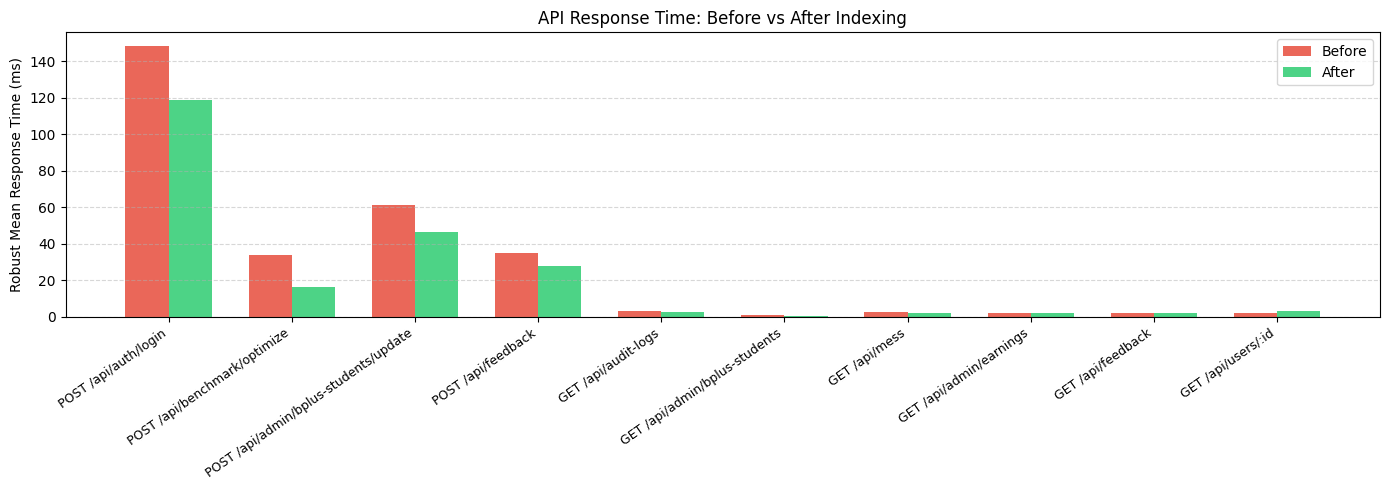

In [6]:
endpoints = merged_sorted["MethodEndpoint"]
x     = np.arange(len(endpoints))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(endpoints) * 1.4), 5))
ax.bar(x - width/2, merged_sorted["RobustMean(ms)_Before"], width, label="Before", color="#e74c3c", alpha=0.85)
ax.bar(x + width/2, merged_sorted["RobustMean(ms)_After"],  width, label="After",  color="#2ecc71", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(endpoints, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Robust Mean Response Time (ms)")
ax.set_title("API Response Time: Before vs After Indexing")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("bar_comparison.png", dpi=150)
plt.show()

## Improvement % Chart

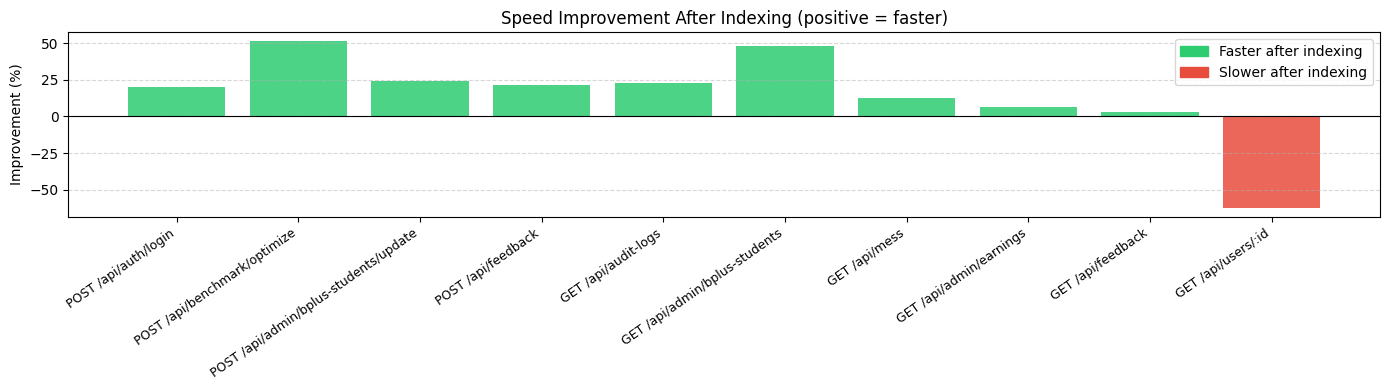

In [7]:
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in merged_sorted["Improvement(%)"]]

fig, ax = plt.subplots(figsize=(max(10, len(endpoints) * 1.4), 4))
ax.bar(x, merged_sorted["Improvement(%)"], color=colors, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(endpoints, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Improvement (%)")
ax.set_title("Speed Improvement After Indexing (positive = faster)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
faster = mpatches.Patch(color="#2ecc71", label="Faster after indexing")
slower = mpatches.Patch(color="#e74c3c", label="Slower after indexing")
ax.legend(handles=[faster, slower])
plt.tight_layout()
plt.savefig("improvement_chart.png", dpi=150)
plt.show()

## Per-Endpoint Time Series (Before vs After Overlaid)

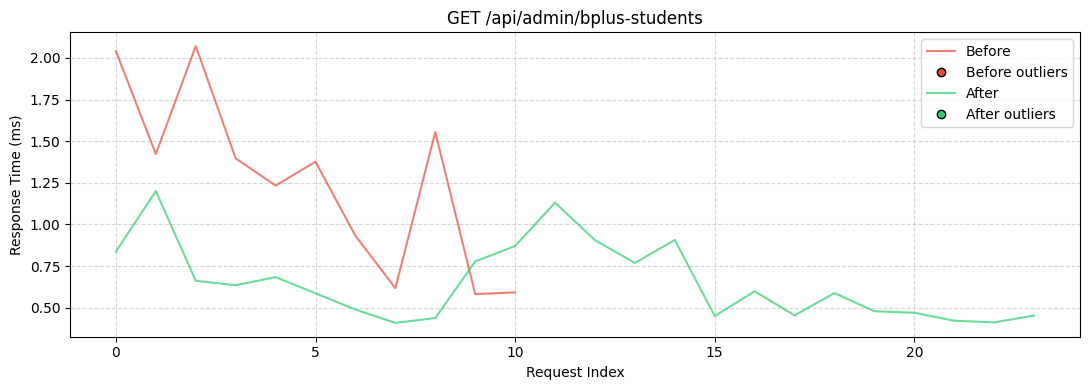

Endpoint : GET /api/admin/bplus-students
  [Before]  Count:11  RobustMean:1.26ms  Median:1.38ms  95th:2.06ms  Max:2.07ms
  [After]  Count:24  RobustMean:0.65ms  Median:0.59ms  95th:1.10ms  Max:1.20ms



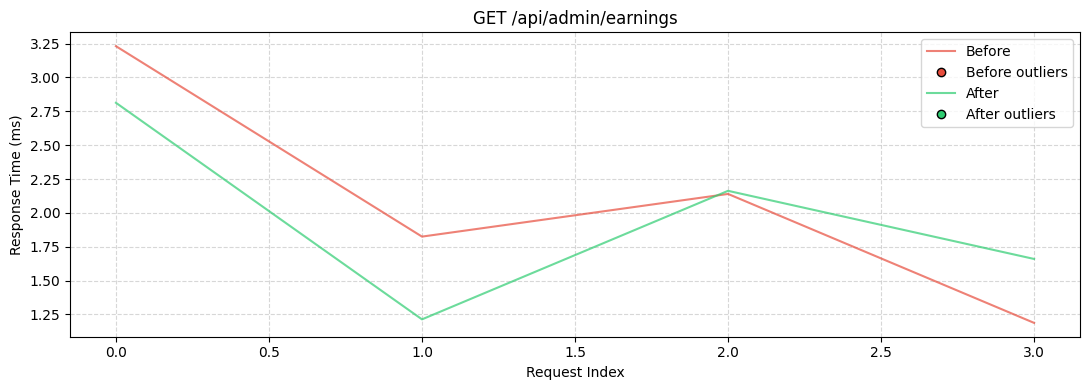

Endpoint : GET /api/admin/earnings
  [Before]  Count:4  RobustMean:2.10ms  Median:1.98ms  95th:3.07ms  Max:3.23ms
  [After]  Count:4  RobustMean:1.96ms  Median:1.91ms  95th:2.72ms  Max:2.81ms



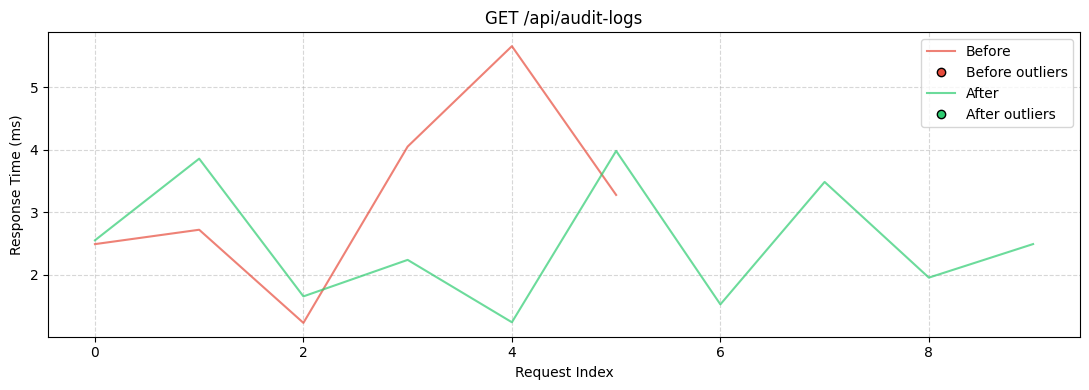

Endpoint : GET /api/audit-logs
  [Before]  Count:6  RobustMean:3.24ms  Median:3.00ms  95th:5.26ms  Max:5.66ms
  [After]  Count:10  RobustMean:2.50ms  Median:2.37ms  95th:3.93ms  Max:3.98ms



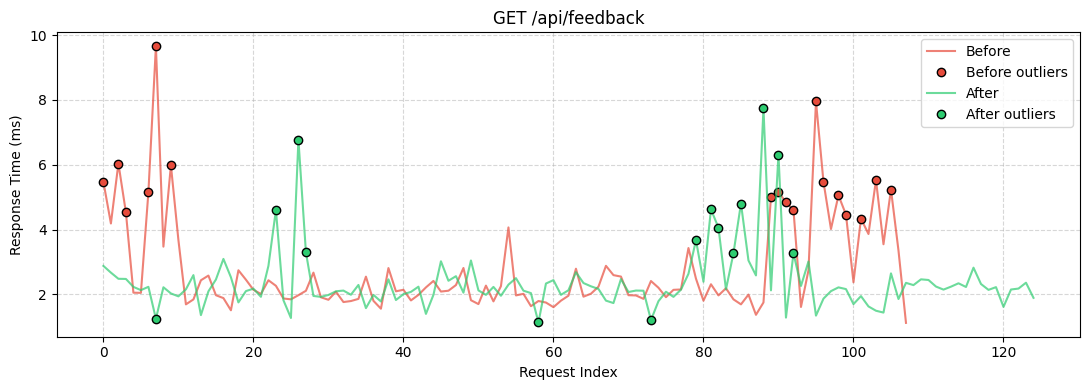

Endpoint : GET /api/feedback
  [Before]  Count:108  RobustMean:2.23ms  Median:2.14ms  95th:5.47ms  Max:9.66ms
  [After]  Count:125  RobustMean:2.16ms  Median:2.16ms  95th:3.98ms  Max:7.74ms



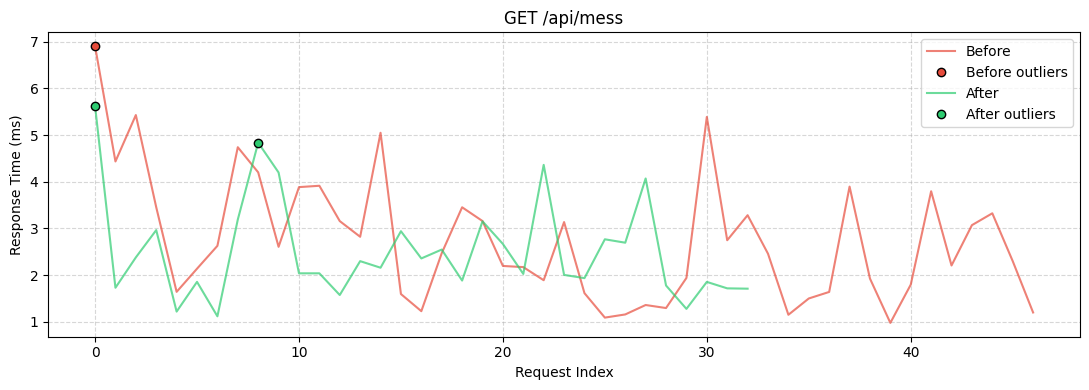

Endpoint : GET /api/mess
  [Before]  Count:47  RobustMean:2.66ms  Median:2.47ms  95th:5.29ms  Max:6.90ms
  [After]  Count:33  RobustMean:2.34ms  Median:2.16ms  95th:4.55ms  Max:5.62ms



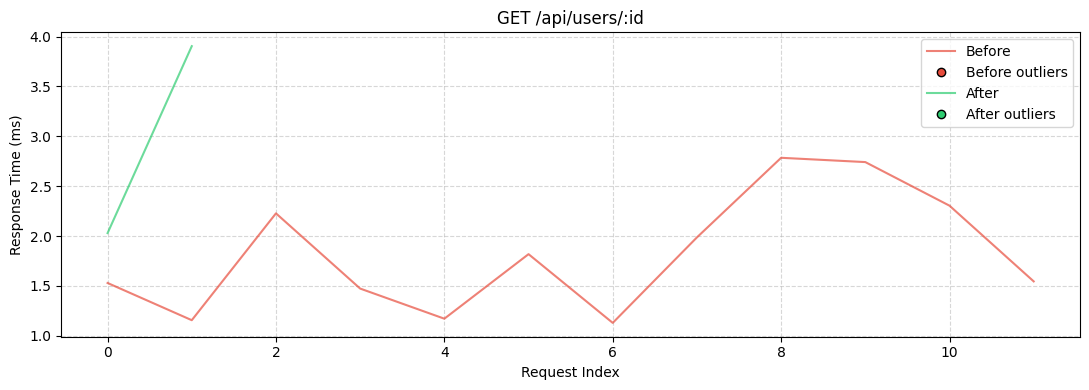

Endpoint : GET /api/users/:id
  [Before]  Count:12  RobustMean:1.82ms  Median:1.68ms  95th:2.76ms  Max:2.79ms
  [After]  Count:2  RobustMean:2.97ms  Median:2.97ms  95th:3.81ms  Max:3.90ms



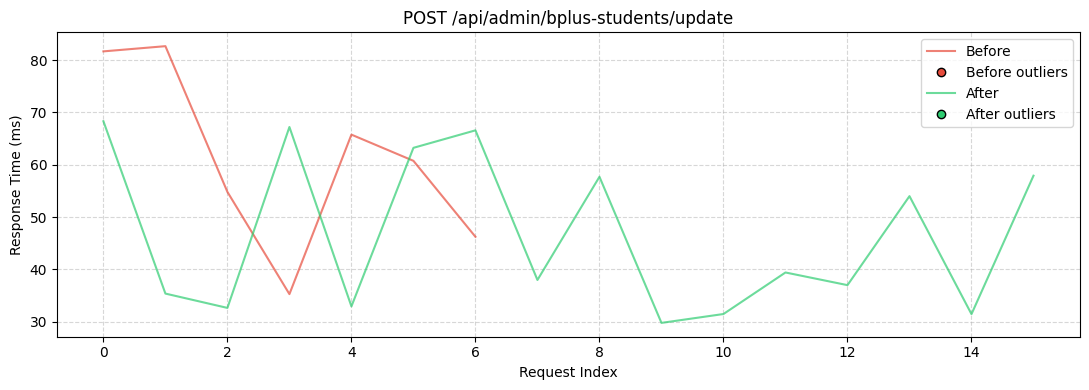

Endpoint : POST /api/admin/bplus-students/update
  [Before]  Count:7  RobustMean:61.03ms  Median:60.75ms  95th:82.38ms  Max:82.68ms
  [After]  Count:16  RobustMean:46.43ms  Median:38.69ms  95th:67.50ms  Max:68.33ms



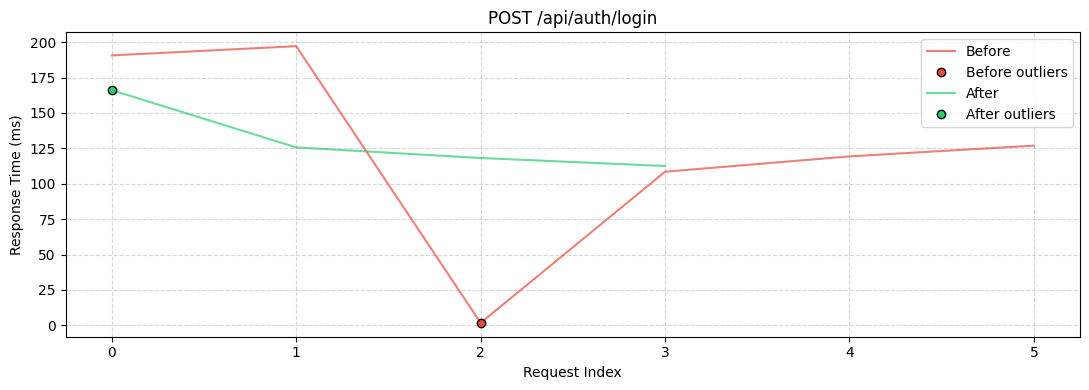

Endpoint : POST /api/auth/login
  [Before]  Count:6  RobustMean:148.48ms  Median:123.10ms  95th:195.51ms  Max:197.14ms
  [After]  Count:4  RobustMean:118.78ms  Median:121.91ms  95th:160.03ms  Max:166.09ms



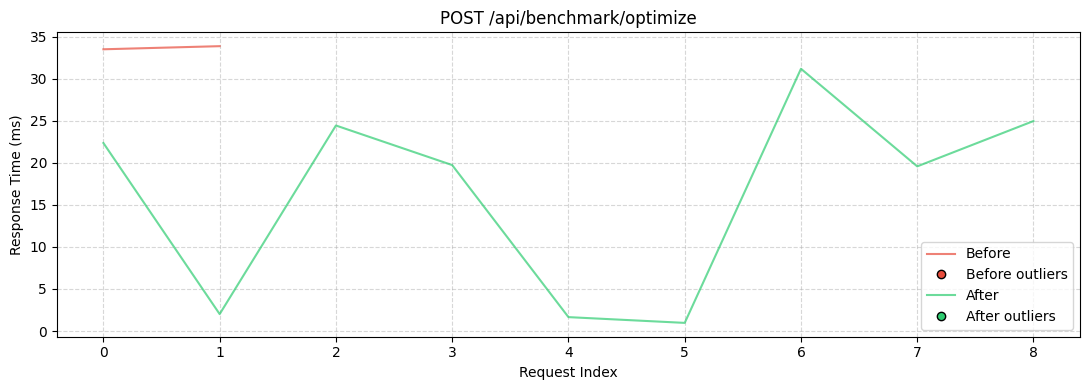

Endpoint : POST /api/benchmark/optimize
  [Before]  Count:2  RobustMean:33.68ms  Median:33.68ms  95th:33.84ms  Max:33.86ms
  [After]  Count:9  RobustMean:16.32ms  Median:19.73ms  95th:28.69ms  Max:31.18ms



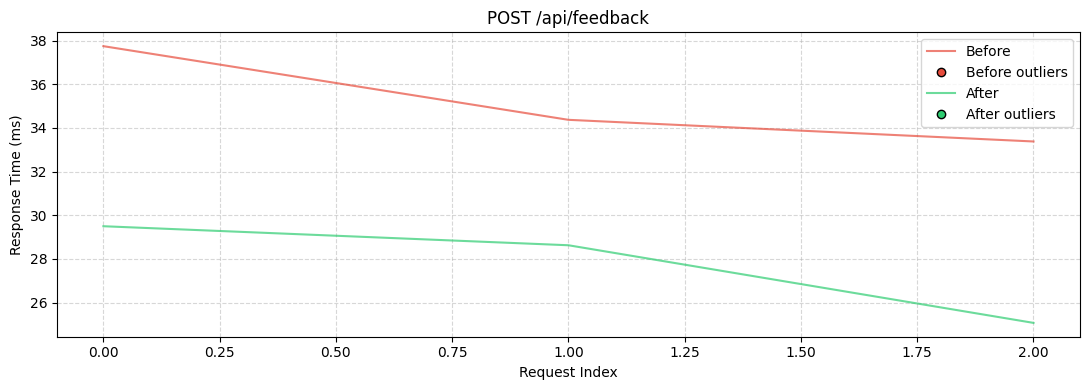

Endpoint : POST /api/feedback
  [Before]  Count:3  RobustMean:35.17ms  Median:34.37ms  95th:37.41ms  Max:37.75ms
  [After]  Count:3  RobustMean:27.73ms  Median:28.62ms  95th:29.41ms  Max:29.50ms



In [8]:
def plot_per_endpoint(df_b, df_a):
    all_keys = sorted(set(df_b["MethodEndpoint"]) | set(df_a["MethodEndpoint"]))

    for key in all_keys:
        row_b = df_b[df_b["MethodEndpoint"] == key]
        row_a = df_a[df_a["MethodEndpoint"] == key]

        fig, ax = plt.subplots(figsize=(11, 4))
        for row, color, label in [(row_b, "#e74c3c", "Before"), (row_a, "#2ecc71", "After")]:
            if row.empty:
                continue
            times = np.array(row.iloc[0]["AllTimes"])
            q1, q3 = np.percentile(times, [25, 75])
            iqr = q3 - q1
            outliers = (times < q1 - 1.5*iqr) | (times > q3 + 1.5*iqr)
            ax.plot(times, color=color, alpha=0.7, label=label)
            ax.plot(np.where(outliers)[0], times[outliers], 'o',
                    color=color, markersize=6, markeredgecolor="black",
                    label=f"{label} outliers")

        ax.set_title(key)
        ax.set_xlabel("Request Index")
        ax.set_ylabel("Response Time (ms)")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        safe = key.replace('/', '_').replace(' ', '_')
        plt.savefig(f"timeseries_{safe}.png", dpi=120)
        plt.show()

        print(f"{'='*55}")
        print(f"Endpoint : {key}")
        for row, label in [(row_b, "Before"), (row_a, "After")]:
            if not row.empty:
                r = row.iloc[0]
                print(f"  [{label}]  Count:{r['Count']}  "
                      f"RobustMean:{r['RobustMean(ms)']:.2f}ms  "
                      f"Median:{r['Median(ms)']:.2f}ms  "
                      f"95th:{r['95thPerc(ms)']:.2f}ms  "
                      f"Max:{r['Max(ms)']:.2f}ms")
        print()

plot_per_endpoint(df_before, df_after)